# Amazon Product Dataset — Exploratory Data Analysis

**Project:** Amazn-AI — Product RAG Chatbot

## Objective

Explore the Amazon product dataset before building the Product RAG pipeline. The goal is to:

1. Understand the raw data — columns, types, size
2. Identify missing values, duplicates, and junk entries
3. Clean numeric fields (prices, ratings, discounts)
4. Visualize key distributions (rating, price, category)
5. Save a **RAG-ready CSV** for `src/rag.py`


## Dataset

**Raw file:** `data/raw/amazon.csv`
**Cleaned file:** `data/cleaned/amazon_cleaned.csv`
**Rows:** 1,465 products
**Columns:** 16

| Column | Type | Description |
|---|---|---|
| `product_id` | str | Unique product identifier |
| `product_name` | str | Product title |
| `category` | str | Hierarchical category path |
| `discounted_price` | float | Current selling price (₹) |
| `actual_price` | float | Original MRP (₹) |
| `discount_percentage` | float | % off |
| `rating` | float | Average rating (1–5) |
| `rating_count` | float | Number of ratings |
| `about_product` | str | Product description |
| `user_id` / `user_name` | str | Reviewer info |
| `review_id` / `review_title` / `review_content` | str | Review data |
| `img_link` / `product_link` | str | URLs |


## Plan

1. **Load & inspect** — `df.info()`, `df.head()`, `df.shape`
2. **Missing values** — count nulls per column
3. **Duplicates** — `df.duplicated().sum()`
4. **Cleaning** — strip ₹, %, commas → convert to numeric
5. **Imputation** — fill 1–2 missing ratings with median
6. **Visualization** — 5 plots (rating, price, category, discount, top-rated)
7. **Save** — export RAG-ready CSV to `data/cleaned/`



## Setup

In [44]:
import os
from pathlib import Path

# Walk up until we find the project root (folder containing 'data')
def find_project_root(marker="data"):
    p = Path.cwd()
    for parent in [p, *p.parents]:
        if (parent / marker).exists():
            return parent
    return p

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)
print("Files here:", [f.name for f in PROJECT_ROOT.iterdir()])

Project root: c:\Users\DELL\OneDrive\Documents\Amazn-AI
Files here: ['.env', '.git', '.gitignore', '.venv', 'app.py', 'Assets', 'data', 'LICENSE', 'notebooks', 'README.md', 'requirements.txt', 'src', 'test.py', 'vector_store']


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Done")

Done


## Step 1: Load Dataset

In [46]:
data_path=("data/raw/amazon.csv")
df=pd.read_csv(data_path)
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## Step 2: Data info

In [47]:
df.info()
df.describe(include='all')
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB
p

## Step 3: Data Cleaning

In [ ]:
df["discounted_price"]    = pd.to_numeric(df["discounted_price"].astype(str).str.replace("₹","",regex=False).str.replace(",","",regex=False), errors="coerce")
df["actual_price"]        = pd.to_numeric(df["actual_price"].astype(str).str.replace("₹","",regex=False).str.replace(",","",regex=False), errors="coerce")
df["discount_percentage"] = pd.to_numeric(df["discount_percentage"].astype(str).str.replace("%","",regex=False), errors="coerce")
df["rating"]              = pd.to_numeric(df["rating"], errors="coerce")
df["rating_count"]        = pd.to_numeric(df["rating_count"], errors="coerce")


In [50]:
df.isnull().sum()

product_id                0
product_name              0
category                  0
discounted_price          0
actual_price              0
discount_percentage       0
rating                    1
rating_count           1139
about_product             0
user_id                   0
user_name                 0
review_id                 0
review_title              0
review_content            0
img_link                  0
product_link              0
dtype: int64

In [51]:
df.dtypes

product_id                 str
product_name               str
category                   str
discounted_price       float64
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count           float64
about_product              str
user_id                    str
user_name                  str
review_id                  str
review_title               str
review_content             str
img_link                   str
product_link               str
dtype: object

### step 3.1: Filling missing values with median

In [52]:
df["rating"]      = df["rating"].fillna(df["rating"].median())
df["rating_count"] = df["rating_count"].fillna(df["rating_count"].median())
df[["rating","rating_count"]].isnull().sum()

rating          0
rating_count    0
dtype: int64

#### Finding Duplciate values and removing them

In [53]:
exact_duplicates = df.duplicated().sum()
print("Exact duplicate rows:", exact_duplicates)

Exact duplicate rows: 0


### Saving cleaned df

In [55]:
df.to_csv("data/cleaned/amazon_cleaned.csv", index=False)
print("saved sucessfully")

saved sucessfully


In [56]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,293.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,293.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,293.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,293.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,293.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## Step 4: Visualization

#### 1: Rating Distribution

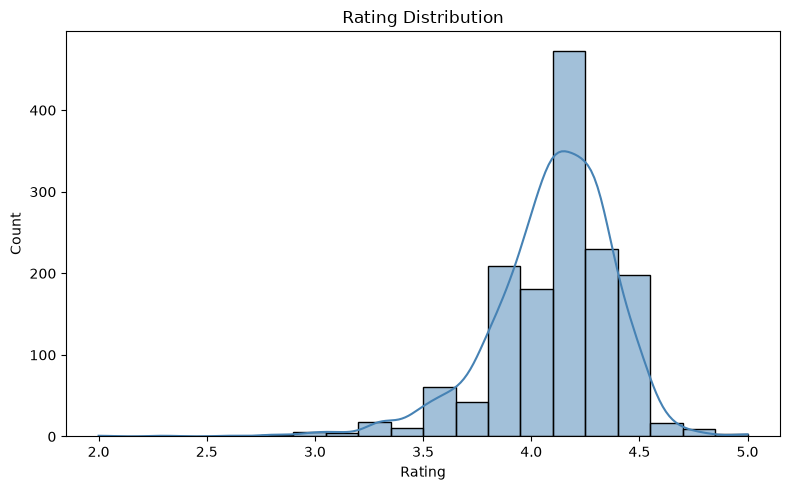

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df["rating"], bins=20, color="steelblue", kde=True)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 2: Discounted price distribution

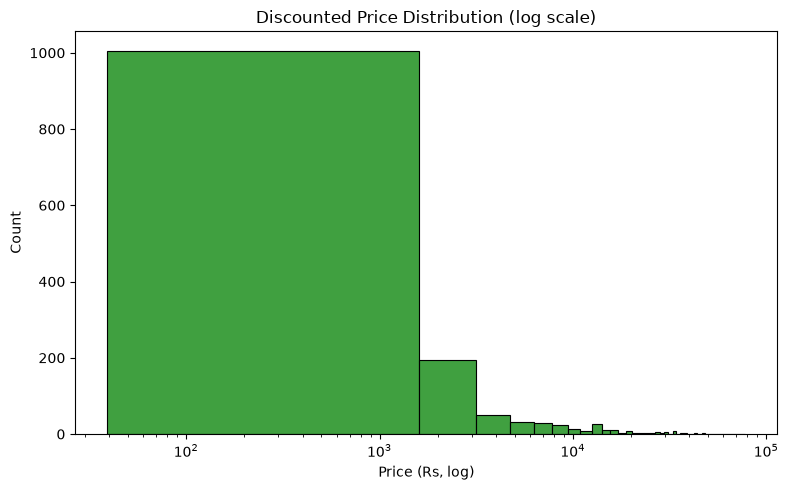

In [59]:
plt.figure(figsize=(8, 5))
sns.histplot(df["discounted_price"], bins=50, color="green")
plt.xscale("log")
plt.title("Discounted Price Distribution (log scale)")
plt.xlabel("Price (Rs, log)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 3: Top 10 Category

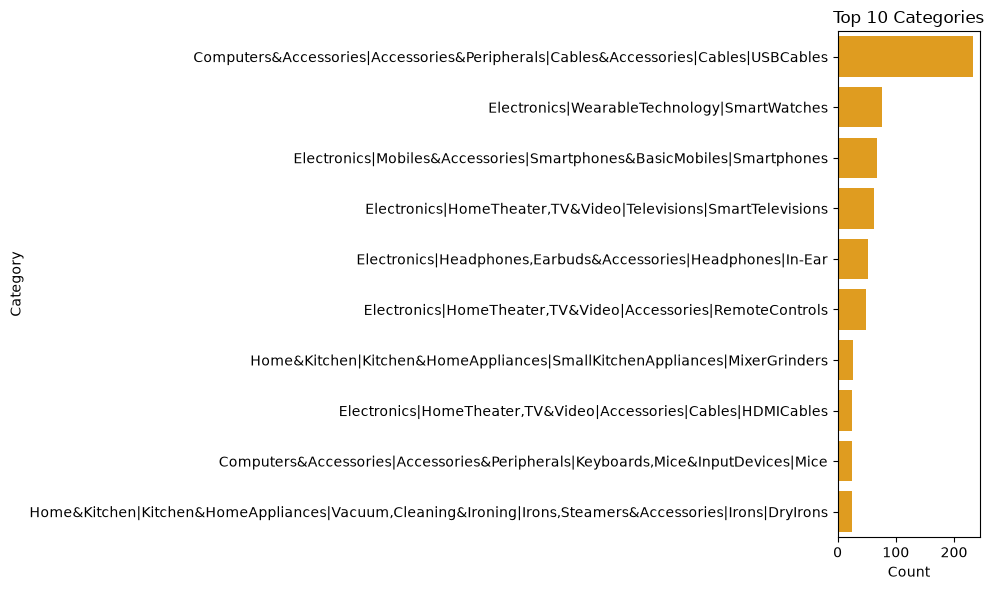

In [60]:
plt.figure(figsize=(10, 6))
top_cat = df["category"].value_counts().head(10)
sns.barplot(x=top_cat.values, y=top_cat.index, color="orange")
plt.title("Top 10 Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

#### 4. Discounted % vs Rating

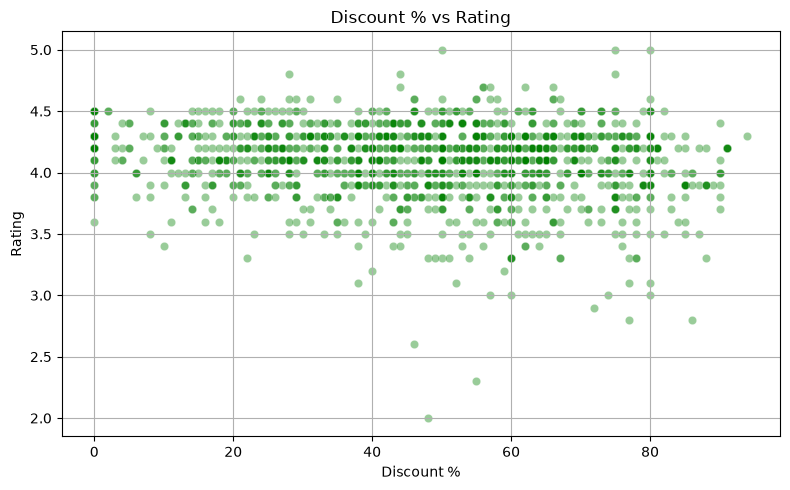

In [63]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="discount_percentage", y="rating", alpha=0.4, color="green")
plt.title("Discount % vs Rating")
plt.xlabel("Discount %")
plt.ylabel("Rating")
plt.tight_layout()
plt.grid(True)
plt.show()

#### 5: Top 10 Most rated products

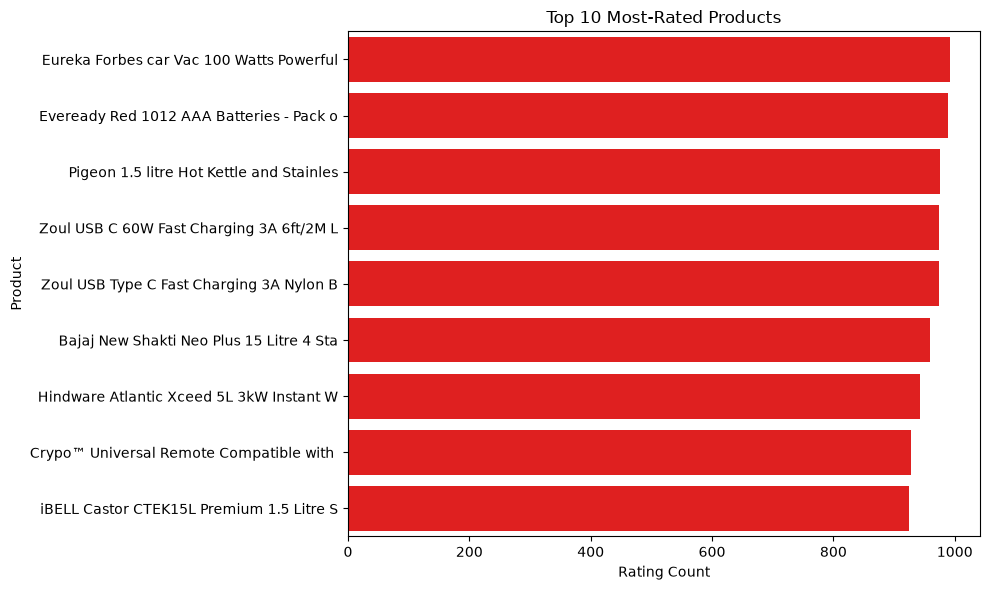

In [65]:
plt.figure(figsize=(10, 6))
top_rated = df.nlargest(10, "rating_count")[["product_name", "rating_count"]].copy()
top_rated["short"] = top_rated["product_name"].str[:40]
sns.barplot(data=top_rated, x="rating_count", y="short", color="red")
plt.title("Top 10 Most-Rated Products")
plt.xlabel("Rating Count")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## All Done about EDA

**Dataset:** `data/cleaned/amazon_cleaned.csv`

### Overview
- **Rows:** 1,465 products
- **Columns:** 16
- **Duplicates:** 0
- **Missing values:** filled (rating & rating_count → median)

### Key Findings
- **Ratings** are left-skewed — most products rated between **4.0 and 4.5**
- **Prices** span a wide range (log-normal distribution) — most products under ₹1,000
- **Discounts** average ~40–60% off actual price
- **Categories** are dominated by cables, accessories, and electronics
- **Top-rated products** have tens of thousands of reviews — high skew

### Cleaning Steps Applied
1. Stripped `₹` and `,` from price columns → converted to `float`
2. Stripped `%` from `discount_percentage` → converted to `float`
3. Coerced `rating` and `rating_count` to numeric
4. Filled missing `rating` / `rating_count` with **median**
5. Verified 0 duplicate rows

### Next Step
→ Build **Product RAG** in `notebooks/product-rag/` using `src/rag.py`  
→ Embeddings: `all-MiniLM-L6-v2`  
→ Vector store: FAISS
